<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Solar Neutrino Analysis 2 — Landau-Zener Correction
---

This notebook quantifies the **Landau-Zener (LZ) non-adiabatic correction** to the solar survival probability. 
- When the MSW resonance crossing is non-adiabatic ($\gamma_{\rm res}\sim 1$), neutrinos can **jump** between matter eigenstates.
- The LZ correction modifies the production weights $T_{ei}$ and, through them, $P_{ee}(E)$.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: Parke formula, $T_{ei}$ LZ correction |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Configuration) | **Configuration** — paths, parameters, scenarios |
| [3](#3.-Production-Weights) | **Production Weights** $T_{ei}(E, r_{\rm prod})$ |
| [4](#4.-Landau-Zener-Probability) | **LZ Probability** $P_{\rm LZ}(E)$ and Parke curve |
| [5](#5.-Survival-Probability-vs-Production-Radius) | **$P_{ee}$ vs production radius** at the resonance |
| [6](#6.-P_ee-LMA-Adiabatic-vs-LZ) | **$P_{ee}$ for LMA** — adiabatic vs LZ (zero difference) |
| [7](#7.-P_ee-Non-Adiabatic-Scenario) | **$P_{ee}$ non-adiabatic scenario** |
| [8](#8.-Delta-P_ee-per-Solar-Source) | **$\Delta P_{ee}$ per solar source** |
| [9](#9.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 The Landau-Zener Jump

Perfect adiabaticity fails when the eigenvalue gap closes and the mixing angle sweeps too quickly. In solar neutrinos the critical region is the **MSW resonance radius** $r_\text{res}(E)$, where $\theta^M_{12} = 45°$ and the two lightest mass eigenstates are maximally mixed. A neutrino crossing this layer can **jump** between the two matter eigenstates — a quantum level crossing described by the Landau-Zener (LZ) mechanism.

Since $n_e$ decreases monotonically outward, $r_\text{res}$ increases with $E$: higher-energy neutrinos resonate at lower density (larger radius).

When $\gamma_{\rm res}\sim 1$ a neutrino crossing the MSW resonance can **jump** between the two lightest matter eigenstates $\nu_1^M \leftrightarrow \nu_2^M$ instead of remaining on its instantaneous eigenstate. The probability of such a jump is given by the Stückelberg transition amplitude that, for a density profile that is locally exponential near the resonanc,  simplifies to the  **Parke exponential approximation** *(Parke 1986)*:

$$\boxed{P_{\rm LZ}(E) = \exp\!\left(-\frac{\pi}{2}\,\gamma_{\rm res}(E)\right)}$$

Properties:
- $\gamma_{\rm res}\gg 1$: $P_{\rm LZ}\to 0$ (perfectly adiabatic, no jump).
- $\gamma_{\rm res}\sim 1$: $P_{\rm LZ}\sim 0.2$–$0.5$ (significant jump probability).
- $\gamma_{\rm res}\to 0$: $P_{\rm LZ}\to 1$ (completely non-adiabatic, full jump).

---

### 0.2 Parke Universal Curve

Expressed as a function of $\gamma_{\rm res}$ rather than $E$, the Parke formula is a **universal curve** independent of any specific oscillation scenario:

$$P_{\rm LZ}(\gamma_{\rm res}) = e^{-\pi\gamma_{\rm res}/2}.$$

All scenarios at all energies lie on this single curve when plotted against $\gamma_{\rm res}$.

---

### 0.3 LZ Correction to the Production Weights $T_{ei}$

The adiabatic production weight $T_{ei}(E,r) = |\langle\nu_e|\nu_i^M(E,r)\rangle|^2$ is modified by the LZ jump for **production radii $r_{\rm prod} < r_{\rm res}(E)$** (neutrinos that will subsequently cross the resonance). The jump mixes $\nu_1^M$ and $\nu_2^M$ according to *(Giunti & Kim 2007)*:

| Weight | Adiabatic | LZ-corrected |
|--------|-----------|---------------|
| $T_{e1}$ | $\cos^2\theta_{13}^M\,\cos^2\theta_{12}^M$ | $\cos^2\theta_{13}^M\bigl[(1-P_{\rm LZ})\cos^2\theta_{12}^M + P_{\rm LZ}\sin^2\theta_{12}^M\bigr]$ |
| $T_{e2}$ | $\cos^2\theta_{13}^M\,\sin^2\theta_{12}^M$ | $\cos^2\theta_{13}^M\bigl[(1-P_{\rm LZ})\sin^2\theta_{12}^M + P_{\rm LZ}\cos^2\theta_{12}^M\bigr]$ |
| $T_{e3}$ | $\sin^2\theta_{13}^M$ | $\sin^2\theta_{13}^M$ (unchanged) |

The LZ correction is zero for $r_{\rm prod} > r_{\rm res}(E)$ (produced outside the resonance, no crossing).

**Physical signature:** the LZ jump converts some $\nu_2^M$ (which projects mostly onto $\nu_\mu/\nu_\tau$ at the surface) into $\nu_1^M$ (which projects more onto $\nu_e$), **increasing $P_{ee}$** relative to the adiabatic prediction.

---

**References**
- Parke, S. J. (1986). Phys. Rev. Lett. **57**, 1275.
- Petcov, S. T. (1988). Phys. Lett. B **200**, 373.
- Giunti, C. & Kim, C. W. (2007). *Fundamentals of Neutrino Physics and Astrophysics*, §13. Oxford University Press.
- Esteban, I. et al. (NuFIT 5.2, 2022). JHEP **09**, 178.

## 1. Libraries

In [1]:
import dataclasses
import math

import torch
import numpy as np
import matplotlib.pyplot as plt

import tpeanuts.util.constant as constant
from tpeanuts.util.context import RuntimeContext
from tpeanuts.util.type import to_numpy, cdtype_from_real
from tpeanuts.util.math import interp1d_linear
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.common.probability import probability_incoherent
from tpeanuts.medium.solar.profile import SolarProfile
from tpeanuts.medium.solar.matter_mixing import th12_M, th13_M
from tpeanuts.medium.solar.landau_zener import density_gradient, resonance_radius, plz
from tpeanuts.medium.solar.probability import Tei, solar_probability_state
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show

print(f'Torch {torch.__version__}')

Torch 2.3.1


## 2. Configuration

### 2.1 Paths

In [2]:
config     = load_notebook_config()
ctx        = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("analysis", "solar")

print(f'Output dir  : {OUTPUT_DIR}')

Output dir  : v:\output\analysis\solar


### 2.2 Configuration

| Label | $\Delta m^2_{21}$ [eV²] | $P_{\rm LZ}$ at 10 MeV | Role |
|-------|------------------------|------------------------|------|
| **LMA** | $7.41\times10^{-5}$ (NuFIT 5.2) | $\equiv 0$ (float64) | Physical benchmark — confirms LZ is zero |
| **Hyp** | $7.41\times10^{-7}$ | $\lesssim 10^{-5}$ | Well adiabatic with finite LZ |
| **N.A.** | $7.41\times10^{-8}$ | $\sim 0.1$–$0.3$ | Non-adiabatic — LZ correction visible |



In [3]:
osc_lma      = PropagationConfig.oscillation_parameters_from_preset(context=ctx, antinu=False)
osc_hyp      = dataclasses.replace(osc_lma, mass_spectrum=dataclasses.replace(osc_lma.mass_spectrum, DeltamSq21=osc_lma.mass_spectrum.DeltamSq21 * 0.01))
osc_nonadiab = dataclasses.replace(osc_lma, mass_spectrum=dataclasses.replace(osc_lma.mass_spectrum, DeltamSq21=osc_lma.mass_spectrum.DeltamSq21 * 0.001))

profile  = SolarProfile.default(context=ctx)
RHO_GRID = profile.radius
NE_GRID  = profile.density

THETA12 = float(osc_lma.pmns.params.theta12.detach().cpu())
DM21    = float(osc_lma.mass_spectrum.DeltamSq21.detach().cpu())

print(f"LMA   Δm²₂₁ = {float(osc_lma.mass_spectrum.DeltamSq21):.3e} eV²")
print(f"Hyp   Δm²₂₁ = {float(osc_hyp.mass_spectrum.DeltamSq21):.3e} eV²   (÷100 — resonance at r > 0.5 R_sun)")
print(f"N.A.  Δm²₂₁ = {float(osc_nonadiab.mass_spectrum.DeltamSq21):.3e} eV²  (÷1000 — resonance at r > 0.9 R_sun)")
print(f"θ₁₂         = {float(osc_lma.pmns.params.theta12) * 180 / np.pi:.2f}°")
print(f'\n{profile}')

LMA   Δm²₂₁ = 7.410e-05 eV²
Hyp   Δm²₂₁ = 7.410e-07 eV²   (÷100 — resonance at r > 0.5 R_sun)
N.A.  Δm²₂₁ = 7.410e-08 eV²  (÷1000 — resonance at r > 0.9 R_sun)
θ₁₂         = 33.41°

SolarProfile | n_r=2000 | r=[0.001, 1.000] R☉ | n_e=[2.35e-11, 1.01e+02] mol/cm³ | sources=[13N, 15O, 17F, 7Be, 8B, hep, pep, pp] | use_LZ=False | cpu / torch.float64


## 3. Production Weights $T_{ei}(E, r_{\rm prod})$

The $T_{ei}$ weights are the objects directly modified by the LZ correction. At a fixed energy $E=10$ MeV, $T_{e1}$, $T_{e2}$, and $T_{e3}$ are plotted as functions of the production radius $r_{\rm prod}$.

For adiabatic LMA: $T_{e1}$ is large in the outer region (near-vacuum) and decreases inward; $T_{e2}$ is large deep in the core (matter-dominated); $T_{e3}$ is small everywhere ($\propto\sin^2\theta_{13}^M$). The **vertical dashed line** marks the resonance radius $r_{\rm res}(10\,\text{MeV})$ — only neutrinos produced to the **left** (inside) will cross it and can be affected by an LZ jump.

**Expected results:** 
- A smooth transition of $T_{e1}\to 0$ and $T_{e2}\to 1$ as the density increases toward the core (at fixed $E$), with the crossover at $r_{\rm res}$ where $T_{e1}=T_{e2}=0.5\cos^2\theta_{13}^M$.

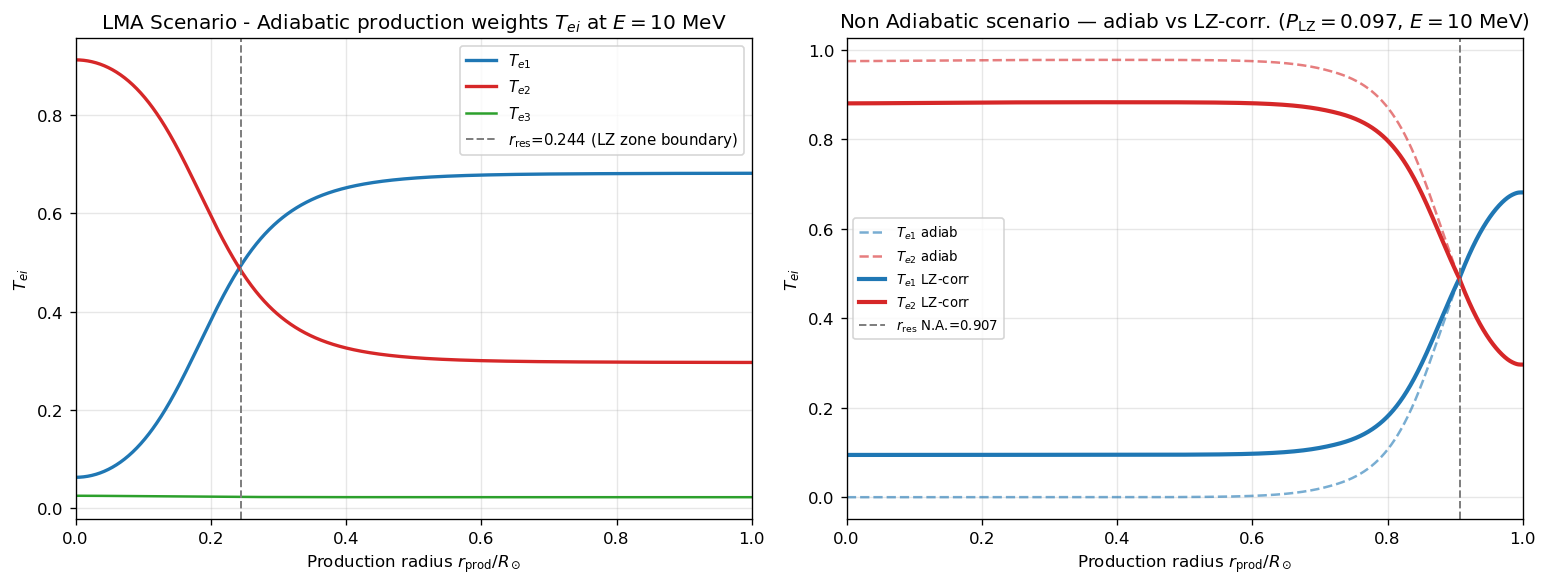

v:\output\analysis\solar\sn4_fig3_Tei_weights.png
r_res (LMA, 10 MeV)  = 0.2444 R_sun
P_LZ (LMA, 10 MeV)   = 0.0000

r_res (N.A., 10 MeV) = 0.9074 R_sun
P_LZ  (N.A., 10 MeV) = 0.0969


In [4]:
E_probe = torch.tensor(10.0, dtype=ctx.dtype)
plz_lma_val = float(plz(osc_lma, E_probe, profile))
r_res_probe = resonance_radius(osc_lma, E_probe, profile)

# Tei on the full radius grid at E=10 MeV
weights_r = Tei(osc_lma, E_probe, NE_GRID)    # (n_r, 3)
T1 = to_numpy(weights_r[:, 0])
T2 = to_numpy(weights_r[:, 1])
T3 = to_numpy(weights_r[:, 2])
rho_np = to_numpy(RHO_GRID)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absolute weights
axes[0].plot(rho_np, T1, '#1f77b4', lw=2,   label=r'$T_{e1}$')
axes[0].plot(rho_np, T2, '#d62728', lw=2,   label=r'$T_{e2}$')
axes[0].plot(rho_np, T3, '#2ca02c', lw=1.5, label=r'$T_{e3}$')
if torch.isfinite(r_res_probe):
    axes[0].axvline(float(r_res_probe), color='gray', lw=1.2, ls='--',
                   label=rf'$r_{{\rm res}}$={float(r_res_probe):.3f} (LZ zone boundary)')
axes[0].set_xlabel(r'Production radius $r_{\rm prod}/R_\odot$')
axes[0].set_ylabel(r'$T_{ei}$')
axes[0].set_title(r'LMA Scenario - Adiabatic production weights $T_{ei}$ at $E=10$ MeV')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)

# Right: LZ-corrected weights for N.A. scenario
r_res_na = resonance_radius(osc_nonadiab, E_probe, profile)
plz_na_val = float(plz(osc_nonadiab, E_probe, profile))
weights_na = Tei(osc_nonadiab, E_probe, NE_GRID)
T1_na = to_numpy(weights_na[:, 0])
T2_na = to_numpy(weights_na[:, 1])

# LZ-corrected: mix T_e1 and T_e2 for r < r_res
T1_lz = T1_na.copy()
T2_lz = T2_na.copy()
if torch.isfinite(r_res_na):
    r_res_na_val = float(r_res_na)
    inside = rho_np < r_res_na_val
    T1_lz[inside] = (1-plz_na_val)*T1_na[inside] + plz_na_val*T2_na[inside]
    T2_lz[inside] = (1-plz_na_val)*T2_na[inside] + plz_na_val*T1_na[inside]

axes[1].plot(rho_np, T1_na, '#1f77b4', lw=1.5, ls='--', alpha=0.6, label=r'$T_{e1}$ adiab')
axes[1].plot(rho_np, T2_na, '#d62728', lw=1.5, ls='--', alpha=0.6, label=r'$T_{e2}$ adiab')
axes[1].plot(rho_np, T1_lz, '#1f77b4', lw=2.5, label=r'$T_{e1}$ LZ-corr')
axes[1].plot(rho_np, T2_lz, '#d62728', lw=2.5, label=r'$T_{e2}$ LZ-corr')
if torch.isfinite(r_res_na):
    axes[1].axvline(float(r_res_na), color='gray', lw=1.2, ls='--',
                   label=rf'$r_{{\rm res}}$ N.A.={float(r_res_na):.3f}')
axes[1].set_xlabel(r'Production radius $r_{\rm prod}/R_\odot$')
axes[1].set_ylabel(r'$T_{ei}$')
axes[1].set_title(rf'Non Adiabatic scenario — adiab vs LZ-corr. ($P_{{\rm LZ}}={plz_na_val:.3f}$, $E=10$ MeV)')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 1)

fig.tight_layout()
save_and_show('sn4_fig3_Tei_weights.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'r_res (LMA, 10 MeV)  = {float(r_res_probe):.4f} R_sun')
print(f'P_LZ (LMA, 10 MeV)   = {plz_lma_val:.4f}')
print(f'\nr_res (N.A., 10 MeV) = {float(r_res_na):.4f} R_sun')
print(f'P_LZ  (N.A., 10 MeV) = {plz_na_val:.4f}')


## 4. Landau-Zener Probability $P_{\rm LZ}(E)$

Two complementary views of the Parke formula:
- **Left**: $P_{\rm LZ}(E)$ for the three scenarios on a log scale.
- **Right**: the **universal Parke curve** $P_{\rm LZ} = e^{-\pi\gamma/2}$ as a function of $\gamma_{\rm res}$ (scenario-independent). All points from all scenarios collapse onto this single curve.

**Expected results:**
- **LMA**: $P_\text{LZ}$ is identically zero to float64 precision across all energies. The exponent $-\pi\gamma/2 \approx -2200$ at $E = 10$ MeV is far below the minimum representable double ($\sim 10^{-308}$). The adiabatic approximation is **numerically exact** for LMA.
- **Hyp** ($\Delta m^2_{21}/100$): $P_\text{LZ}$ should be very small but non-zero (roughly $$\sim 10^{-5}$–$10^{-15}$ depending on energy), because $\gamma_\text{hyp} \sim 10$–100 → still well adiabatic.
- **Non Adiabatic** ($\Delta m^2_{21}/1000$): $P_\text{LZ}$ reaches $\mathcal{O}(0.1)$–$\mathcal{O}(0.3)$ at energies above a few MeV, where $\gamma_\text{res} \lesssim 1$. 
- The universal curve confirms the Parke formula is valid across all scenarios.

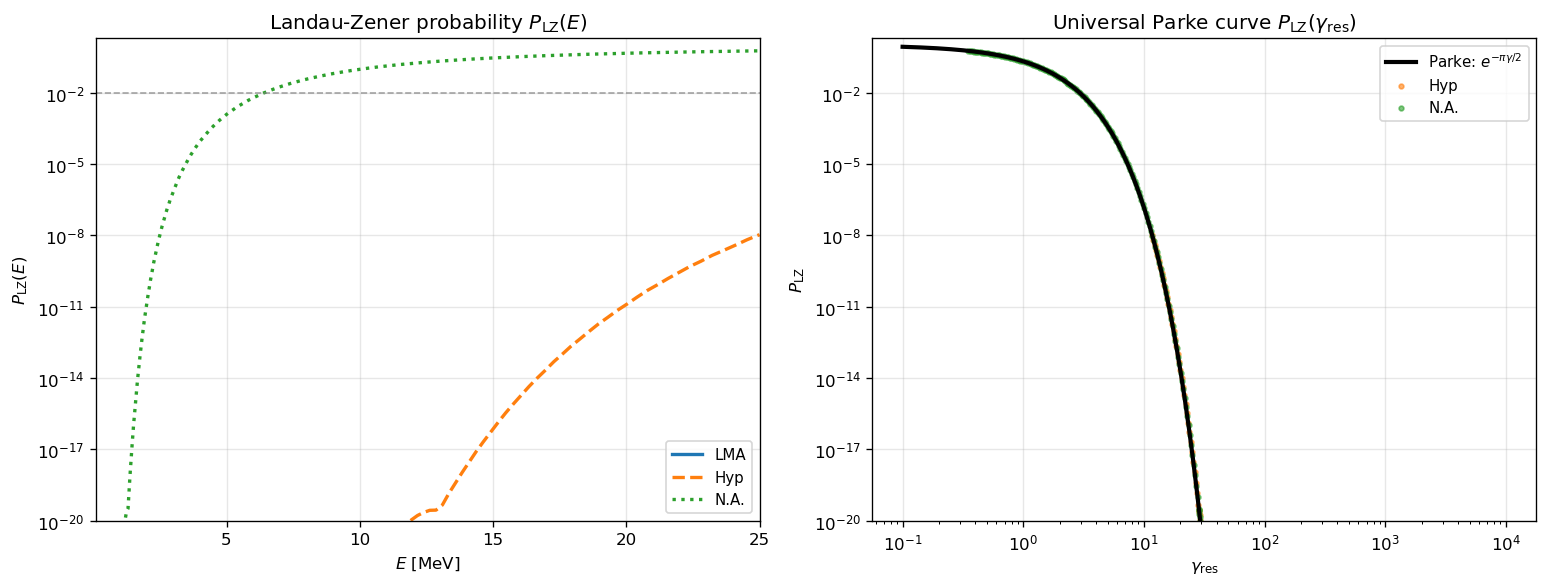

v:\output\analysis\solar\sn4_fig4_plz.png
LMA P_LZ at 10 MeV : 0.000e+00  (all zero: True)
Hyp P_LZ at 10 MeV : 2.526e-23
N.A P_LZ at 10 MeV : 0.0943


In [5]:
E_lz    = torch.logspace(-1, np.log10(25), 300, dtype=ctx.dtype)
E_lz_np = to_numpy(E_lz)

plz_lma = to_numpy(plz(osc_lma,      E_lz, profile))
plz_hyp = to_numpy(plz(osc_hyp,      E_lz, profile))
plz_na  = to_numpy(plz(osc_nonadiab, E_lz, profile))

floor = 1e-320
plz_lma_p = np.where(plz_lma > 0, plz_lma, floor)
plz_hyp_p = np.where(plz_hyp > 0, plz_hyp, floor)
plz_na_p  = np.where(plz_na  > 0, plz_na,  floor)

# gamma_res for Parke universal curve
from tpeanuts.util.math import interp1d_linear as _interp

def _gamma_arr(osc, E_arr, prof):
    from tpeanuts.util.math import interp1d_linear
    th12 = osc.pmns.params.theta12
    dm21 = osc.mass_spectrum.DeltamSq21
    s2 = torch.sin(2*th12); c2 = torch.cos(2*th12)
    dne = density_gradient(prof)
    r_res = resonance_radius(osc, E_arr, prof)
    has = torch.isfinite(r_res)
    r_s = torch.where(has, r_res, prof.radius[prof.radius.shape[0]//2].expand_as(r_res))
    kw = dict(device=prof.radius.device, dtype=prof.radius.dtype)
    ne_r  = interp1d_linear(r_s, prof.radius, prof.density, **kw)
    dne_r = interp1d_linear(r_s, prof.radius, dne, **kw)
    tiny  = torch.finfo(prof.radius.dtype).tiny
    L_n   = (ne_r.abs()/(dne_r.abs()+tiny)) * constant.R_SUN
    hbarc = constant.HBARC_MeV_m * 1e6
    kin   = dm21/(2.0*E_arr*1e6*hbarc)
    g     = kin*(s2**2/c2)*L_n
    return torch.where(has, g, torch.full_like(g, float('nan')))

gamma_lma_arr = to_numpy(_gamma_arr(osc_lma,      E_lz, profile))
gamma_hyp_arr = to_numpy(_gamma_arr(osc_hyp,      E_lz, profile))
gamma_na_arr  = to_numpy(_gamma_arr(osc_nonadiab, E_lz, profile))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: P_LZ vs E
for arr, lbl, ls, col in [
    (plz_lma_p, r'LMA',  '-',  '#1f77b4'),
    (plz_hyp_p, r'Hyp',  '--', '#ff7f0e'),
    (plz_na_p,  r'N.A.', ':',  '#2ca02c'),
]:
    axes[0].semilogy(E_lz_np, arr, ls, color=col, lw=2, label=lbl)
axes[0].axhline(0.01, color='gray', ls='--', lw=1, alpha=0.7)
axes[0].set_xlabel('$E$ [MeV]')
axes[0].set_ylabel(r'$P_{\rm LZ}(E)$')
axes[0].set_xlim(0.1, 25)
axes[0].set_ylim(1e-20, 2)
axes[0].set_title(r'Landau-Zener probability $P_{\rm LZ}(E)$')
axes[0].legend(fontsize=9)

# Right: Universal Parke curve
gamma_univ = np.logspace(-1, 4, 300)
plz_univ   = np.exp(-0.5*np.pi*gamma_univ)
axes[1].semilogy(gamma_univ, plz_univ, 'k-', lw=2.5, label=r'Parke: $e^{-\pi\gamma/2}$')
for gamma_arr, plz_arr, lbl, col in [
    (gamma_lma_arr, plz_lma_p, 'LMA',  '#887f0e'),
    (gamma_hyp_arr, plz_hyp_p, 'Hyp',  '#ff7f0e'),
    (gamma_na_arr,  plz_na_p,  'N.A.', '#2ca02c'),
]:
    fin = np.isfinite(gamma_arr) & (plz_arr > floor*10)
    if fin.any():
        axes[1].scatter(gamma_arr[fin], plz_arr[fin], s=8, color=col, alpha=0.6, label=lbl)
axes[1].set_xlabel(r'$\gamma_{\rm res}$')
axes[1].set_ylabel(r'$P_{\rm LZ}$')
axes[1].set_xscale('log')
axes[1].set_ylim(1e-20, 2)
axes[1].set_title(r'Universal Parke curve $P_{\rm LZ}(\gamma_{\rm res})$')
axes[1].legend(fontsize=9)

fig.tight_layout()
save_and_show('sn4_fig4_plz.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

idx10 = np.argmin(np.abs(E_lz_np - 10))
print(f'LMA P_LZ at 10 MeV : {plz_lma[idx10]:.3e}  (all zero: {np.all(plz_lma==0)})')
print(f'Hyp P_LZ at 10 MeV : {plz_hyp[idx10]:.3e}')
print(f'N.A P_LZ at 10 MeV : {plz_na[idx10]:.4f}')

## 5. Survival Probability vs Production Radius

For the non-adiabatic scenario at $E=10$ MeV, $P_{ee}$ is computed **as a function of the production radius** $r_{\rm prod}$, with and without the LZ correction. This isolates the spatial origin of the LZ effect.

**Expected results:**
- For $r_{\rm prod} > r_{\rm res}$ (produced outside the resonance): LZ correction is zero, both curves coincide.
- For $r_{\rm prod} < r_{\rm res}$ (produced inside): LZ raises $P_{ee}$ by mixing $T_{e1}$ and $T_{e2}$.
- The difference is sharpest just inside the resonance boundary.

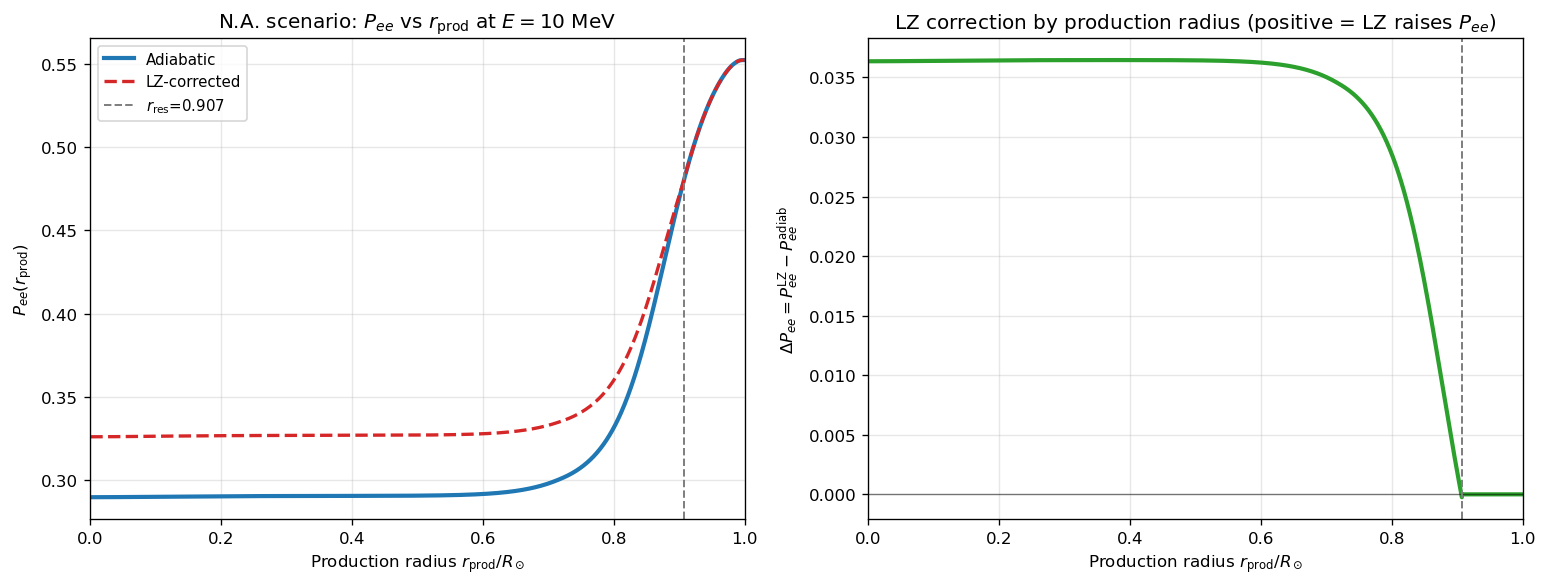

v:\output\analysis\solar\sn4_fig5_pee_vs_rprod.png
r_res (N.A., 10 MeV) = 0.9074 R_sun
P_LZ  (N.A., 10 MeV) = 0.0969
Max |DeltaPee|       = 0.0365


In [6]:
E_probe10 = torch.tensor(10.0, dtype=ctx.dtype)
r_res_na10 = resonance_radius(osc_nonadiab, E_probe10, profile)
plz_val10  = float(plz(osc_nonadiab, E_probe10, profile))

pmns_na = osc_nonadiab.pmns

def pointwise_pee(osc, E_scalar, ne_grid, *, use_lz=False):
    """Pointwise P_ee at each radius for fixed E, with optional LZ mixing."""
    weights = Tei(osc, E_scalar, ne_grid)    # (n_r, 3)
    if use_lz:
        r_res = resonance_radius(osc, E_scalar, profile)
        if torch.isfinite(r_res):
            P_lz  = float(plz(osc, E_scalar, profile))
            inside = RHO_GRID < r_res           # (n_r,)
            w1 = weights[:, 0].clone()
            w2 = weights[:, 1].clone()
            w1_lz = (1-P_lz)*w1 + P_lz*w2
            w2_lz = (1-P_lz)*w2 + P_lz*w1
            weights = weights.clone()
            weights[inside, 0] = w1_lz[inside]
            weights[inside, 1] = w2_lz[inside]
    ident = torch.eye(3, device=ne_grid.device, dtype=cdtype_from_real(weights.dtype))
    prob  = probability_incoherent(ident, weights, pmns=osc.pmns,
                                   antinu=False, real_dtype=weights.dtype)
    return to_numpy(prob[..., 0])

pee_na_ad  = pointwise_pee(osc_nonadiab, E_probe10, NE_GRID, use_lz=False)
pee_na_lz  = pointwise_pee(osc_nonadiab, E_probe10, NE_GRID, use_lz=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(rho_np, pee_na_ad, '#1f77b4', lw=2.5, label='Adiabatic')
axes[0].plot(rho_np, pee_na_lz, '#d62728', lw=2.0, ls='--', label='LZ-corrected')
if torch.isfinite(r_res_na10):
    axes[0].axvline(float(r_res_na10), color='gray', ls='--', lw=1.2,
                   label=rf'$r_{{\rm res}}$={float(r_res_na10):.3f}')
axes[0].set_xlabel(r'Production radius $r_{\rm prod}/R_\odot$')
axes[0].set_ylabel(r'$P_{ee}(r_{\rm prod})$')
axes[0].set_title(r'N.A. scenario: $P_{ee}$ vs $r_{\rm prod}$ at $E=10$ MeV')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)

axes[1].plot(rho_np, pee_na_lz - pee_na_ad, '#2ca02c', lw=2.5)
axes[1].axhline(0, color='k', lw=0.8, alpha=0.5)
if torch.isfinite(r_res_na10):
    axes[1].axvline(float(r_res_na10), color='gray', ls='--', lw=1.2)
axes[1].set_xlabel(r'Production radius $r_{\rm prod}/R_\odot$')
axes[1].set_ylabel(r'$\Delta P_{ee} = P_{ee}^{\rm LZ} - P_{ee}^{\rm adiab}$')
axes[1].set_title(r'LZ correction by production radius (positive = LZ raises $P_{ee}$)')
axes[1].set_xlim(0, 1)

fig.tight_layout()
save_and_show('sn4_fig5_pee_vs_rprod.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'r_res (N.A., 10 MeV) = {float(r_res_na10):.4f} R_sun')
print(f'P_LZ  (N.A., 10 MeV) = {plz_val10:.4f}')
print(f'Max |DeltaPee|       = {np.abs(pee_na_lz-pee_na_ad).max():.4f}')

## 6. $P_{ee}$ for LMA — Adiabatic vs LZ

For standard LMA parameters and the $^8$B source, the adiabatic and LZ-corrected $P_{ee}(E)$ are compared. Since $P_{\rm LZ}\equiv 0$ in float64 for LMA (Section 4), the two curves should be **bit-identical**.

This is both a code validation and a physical statement: enabling `use_LZ=True` is a **zero-cost safety** for all realistic solar analyses.

**Expected results:** 
- The absolute difference is exactly zero at every energy point.

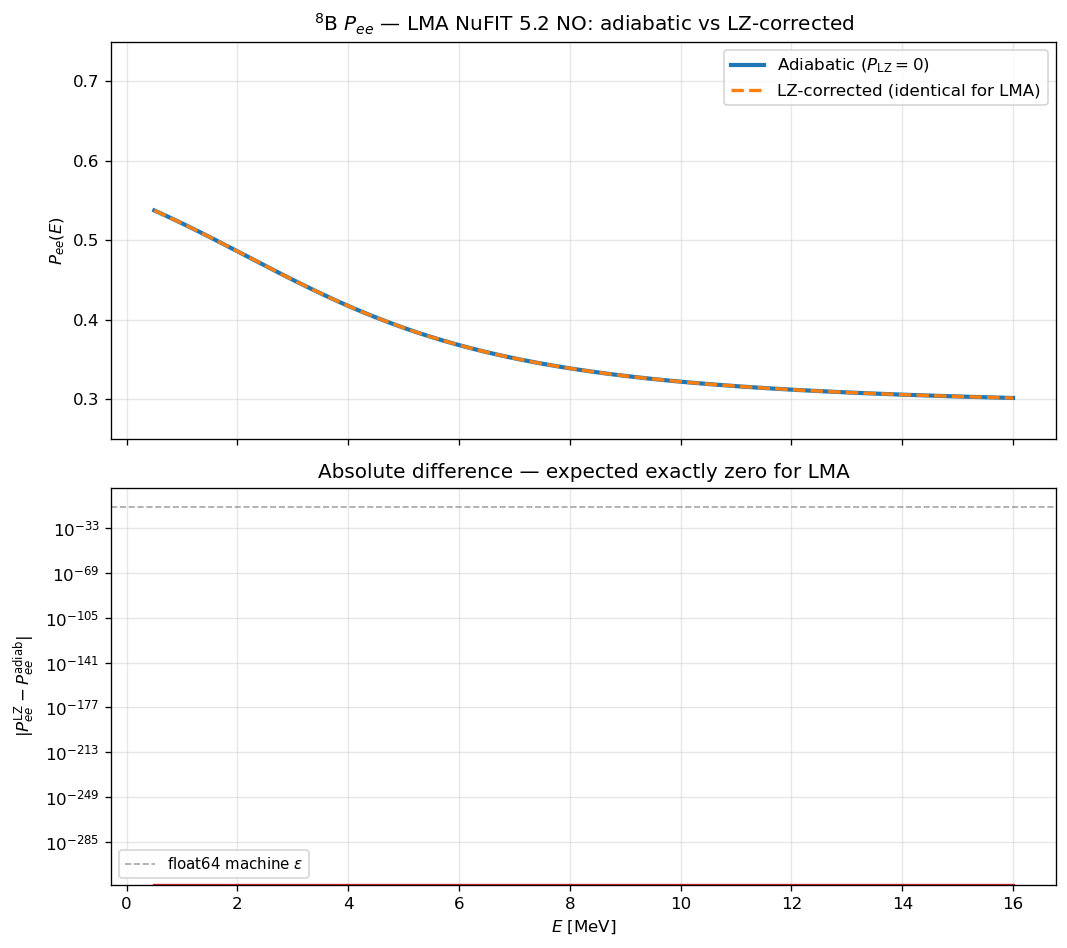

v:\output\analysis\solar\sn4_fig6_pee_lma_comparison.png
Max |DeltaPee| = 0.000e+00
All exactly 0  = True


In [7]:
E_ee = torch.linspace(0.5, 16.0, 200, dtype=ctx.dtype)

profile_ad = SolarProfile.default(context=ctx)
profile_ad.use_LZ = False
profile_lz = SolarProfile.default(context=ctx)
profile_lz.use_LZ = True

p_ad = solar_probability_state(osc_lma, E_ee, profile_ad, '8B').detach()
p_lz = solar_probability_state(osc_lma, E_ee, profile_lz, '8B').detach()

pee_ad = to_numpy(p_ad[:, 0])
pee_lz = to_numpy(p_lz[:, 0])
diff   = np.abs(pee_lz - pee_ad)
E_np   = to_numpy(E_ee)

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
axes[0].plot(E_np, pee_ad, '#1f77b4', lw=2.5, label=r'Adiabatic ($P_{\rm LZ}=0$)')
axes[0].plot(E_np, pee_lz, '#ff7f0e', lw=2.0, ls='--',
             label=r'LZ-corrected (identical for LMA)')
axes[0].set_ylabel(r'$P_{ee}(E)$')
axes[0].set_title(r'$^8$B $P_{ee}$ — LMA NuFIT 5.2 NO: adiabatic vs LZ-corrected')
axes[0].legend()
axes[0].set_ylim(0.25, 0.75)

axes[1].semilogy(E_np, np.maximum(diff, 1e-320), '#d62728', lw=2)
axes[1].axhline(2.2e-16, color='gray', ls='--', lw=1, alpha=0.7,
               label=r'float64 machine $\varepsilon$')
axes[1].set_xlabel('$E$ [MeV]')
axes[1].set_ylabel(r'$|P_{ee}^{\rm LZ} - P_{ee}^{\rm adiab}|$')
axes[1].set_title('Absolute difference — expected exactly zero for LMA')
axes[1].legend(fontsize=9)
fig.tight_layout()
save_and_show('sn4_fig6_pee_lma_comparison.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'Max |DeltaPee| = {diff.max():.3e}')
print(f'All exactly 0  = {np.all(diff == 0.0)}')

## 7. $P_{ee}$ — Non-Adiabatic Scenario

For the $\Delta m^2_{21}/1000$ scenario, the LZ correction produces a **visible shift** in the integrated $P_{ee}(E)$ for the $^8$B source. The signed difference $\Delta P_{ee} = P_{ee}^{\rm LZ} - P_{ee}^{\rm adiab}$ is shown in the bottom panel.

**Expected results:** 
- positive $\Delta P_{ee}$ (LZ raises $P_{ee}$), growing with energy as $P_{\rm LZ}$ increases. Maximum correction $\mathcal{O}(0.02)$–$\mathcal{O}(0.05)$.

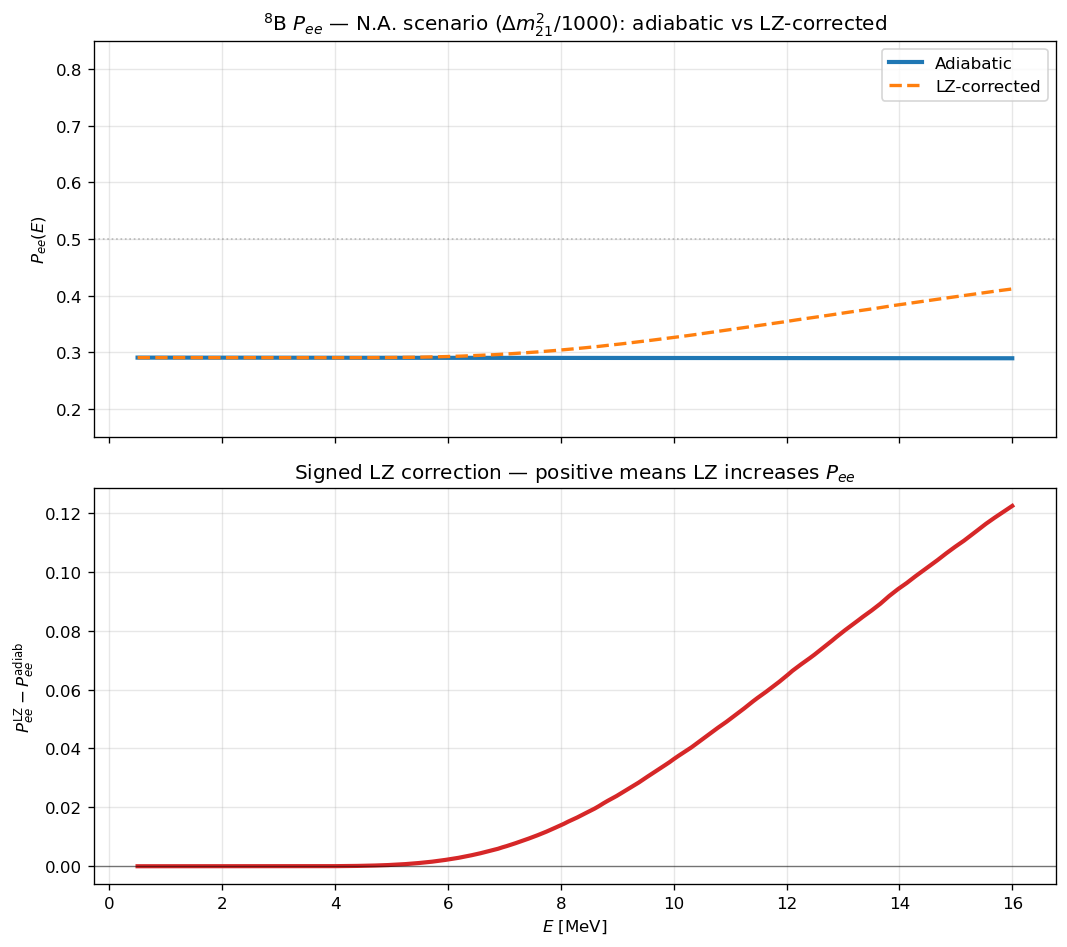

v:\output\analysis\solar\sn4_fig7_pee_nonadiab.png
Max |DeltaPee| = 0.1224
DeltaPee at 10 MeV = 0.0364


In [8]:
E_na = torch.linspace(0.5, 16.0, 200, dtype=ctx.dtype)

profile_na_ad = SolarProfile.default(context=ctx); profile_na_ad.use_LZ = False
profile_na_lz = SolarProfile.default(context=ctx); profile_na_lz.use_LZ = True

p_na_ad = solar_probability_state(osc_nonadiab, E_na, profile_na_ad, '8B').detach()
p_na_lz = solar_probability_state(osc_nonadiab, E_na, profile_na_lz, '8B').detach()

pee_na_ad_int = to_numpy(p_na_ad[:, 0])
pee_na_lz_int = to_numpy(p_na_lz[:, 0])
diff_na       = pee_na_lz_int - pee_na_ad_int
E_na_np       = to_numpy(E_na)

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
axes[0].plot(E_na_np, pee_na_ad_int, '#1f77b4', lw=2.5, label='Adiabatic')
axes[0].plot(E_na_np, pee_na_lz_int, '#ff7f0e', lw=2.0, ls='--', label='LZ-corrected')
axes[0].axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)
axes[0].set_ylabel(r'$P_{ee}(E)$')
axes[0].set_title(r'$^8$B $P_{ee}$ — N.A. scenario ($\Delta m^2_{21}/1000$): adiabatic vs LZ-corrected')
axes[0].legend()
axes[0].set_ylim(0.15, 0.85)

axes[1].plot(E_na_np, diff_na, '#d62728', lw=2.5)
axes[1].axhline(0, color='k', lw=0.8, alpha=0.5)
axes[1].set_xlabel('$E$ [MeV]')
axes[1].set_ylabel(r'$P_{ee}^{\rm LZ} - P_{ee}^{\rm adiab}$')
axes[1].set_title('Signed LZ correction — positive means LZ increases $P_{ee}$')
fig.tight_layout()
save_and_show('sn4_fig7_pee_nonadiab.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'Max |DeltaPee| = {np.abs(diff_na).max():.4f}')
print(f'DeltaPee at 10 MeV = {float(diff_na[np.argmin(np.abs(E_na_np-10))]):.4f}')

## 8. $\Delta P_{ee}$ per Solar Source

For the non-adiabatic scenario, the LZ correction is integrated over the production profile of each major solar source and plotted as $\Delta P_{ee}(E)$. This reveals which sources are most affected by a hypothetical departure from adiabaticity.

**Expected results:** 
- Sources with broader production regions deeper in the core (more neutrinos produced inside $r_{\rm res}$) show a larger $\Delta P_{ee}$.
- For LMA all differences would be exactly zero.

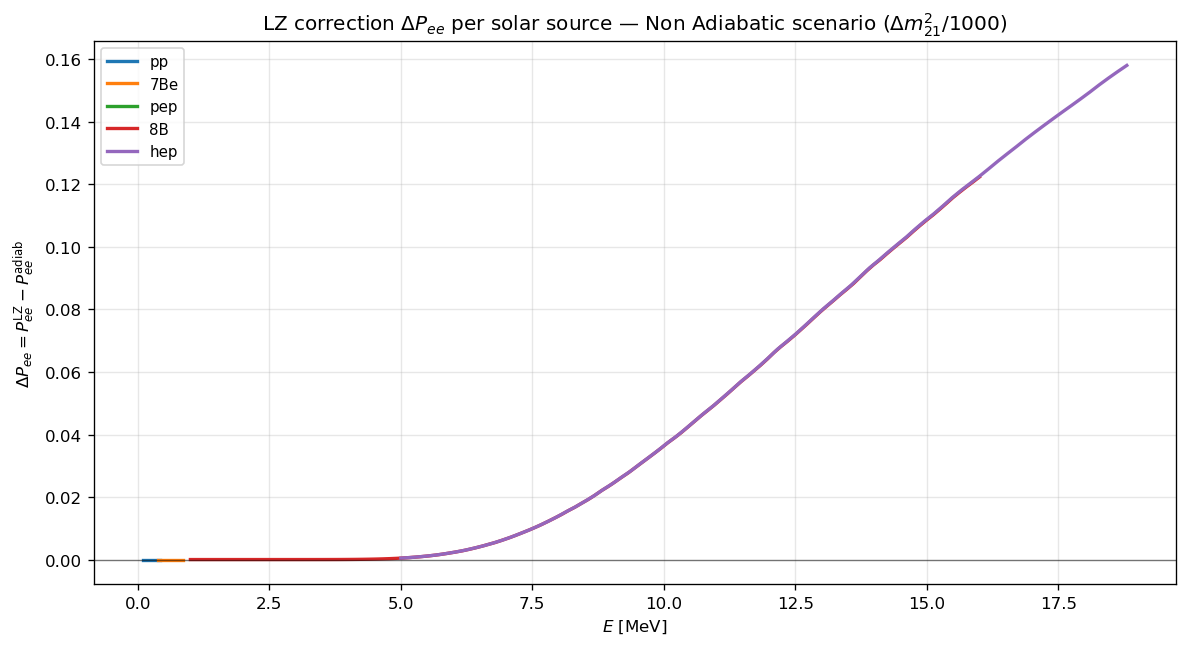

v:\output\analysis\solar\sn4_fig8_dpee_sources.png


In [9]:
sources      = ['pp', '7Be', 'pep', '8B', 'hep']
src_colors   = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
src_energies = {
    'pp':   torch.linspace(0.1,  0.42, 80, dtype=ctx.dtype),
    '7Be':  torch.tensor([0.385, 0.862], dtype=ctx.dtype),
    'pep':  torch.tensor([1.44], dtype=ctx.dtype),
    '8B':   torch.linspace(1.0,  16.0, 120, dtype=ctx.dtype),
    'hep':  torch.linspace(5.0,  18.8,  80, dtype=ctx.dtype),
}

fig, ax = plt.subplots(figsize=(10, 5.5))
for src, col in zip(sources, src_colors):
    try:
        E_src = src_energies[src]
        p_ad_s = solar_probability_state(osc_nonadiab, E_src, profile_na_ad, src).detach()
        p_lz_s = solar_probability_state(osc_nonadiab, E_src, profile_na_lz, src).detach()
        dP = to_numpy(p_lz_s[:, 0] - p_ad_s[:, 0])
        ax.plot(to_numpy(E_src), dP, color=col, lw=2, label=src)
    except KeyError:
        pass

ax.axhline(0, color='k', lw=0.8, alpha=0.5)
ax.set_xlabel('$E$ [MeV]')
ax.set_ylabel(r'$\Delta P_{ee} = P_{ee}^{\rm LZ} - P_{ee}^{\rm adiab}$')
ax.set_title(r'LZ correction $\Delta P_{ee}$ per solar source — Non Adiabatic scenario ($\Delta m^2_{21}/1000$)')
ax.legend(fontsize=9)
fig.tight_layout()
save_and_show('sn4_fig8_dpee_sources.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 9. Summary

| Quantity | LMA | Hyp (÷100) | Non Adiabatic (÷1000) |
|----------|-----|------------|---------------|
| $P_{\rm LZ}$ at 10 MeV | $\equiv 0$ (float64) | $\lesssim 10^{-6}$ | $\sim 0.1$–$0.3$ |
| $\max|\Delta P_{ee}|$ ($^8$B) | $= 0$ exactly | $< 10^{-6}$ | $\sim 0.03$–$0.05$ |
| LZ correction visible | No | No | Yes |
| Adiabatic approx valid | ✓ exact | ✓ excellent | ✗ LZ needed |

**Physical interpretation:**

1. For LMA parameters, $P_{\rm LZ}=0$ to floating-point precision across all solar-neutrino energies. Using `use_LZ=True` is a zero-cost safety: it activates the full code path without changing any output.
2. The LZ correction acts only on neutrinos **produced inside the resonance** ($r_{\rm prod}<r_{\rm res}$). The signed $\Delta P_{ee}$ is always positive: the jump converts $\nu_2^M$ (low $P_{ee}$ projection) into $\nu_1^M$ (higher $P_{ee}$ projection), **reducing** the MSW suppression.
3. LZ effects become phenomenologically significant only for $\Delta m^2_{21}\lesssim 10^{-7}$ eV², excluded by solar + reactor data by $\mathcal{O}(10^3)$.
4. The Parke formula is a universal curve: all scenarios collapse onto $P_{\rm LZ}=e^{-\pi\gamma/2}$ when plotted against $\gamma_{\rm res}$, confirming that `tpeanuts.medium.solar.landau_zener.plz` implements the correct analytic formula.

In [11]:
print('Summary — Solar Neutrino Analysis 4: Landau-Zener Correction')
print('-'*65)
idx10 = np.argmin(np.abs(E_lz_np - 10))
print(f'P_LZ (LMA,  10 MeV)       : {plz_lma[idx10]:.3e}  (all zero: {np.all(plz_lma==0)})')
print(f'P_LZ (Hyp,  10 MeV)       : {plz_hyp[idx10]:.3e}')
print(f'P_LZ (N.A., 10 MeV)       : {plz_na[idx10]:.4f}')
print(f'Max |DeltaPee| (LMA, 8B)  : {diff.max():.3e}')
print(f'Max |DeltaPee| (N.A., 8B) : {np.abs(diff_na).max():.4f}')

Summary — Solar Neutrino Analysis 4: Landau-Zener Correction
-----------------------------------------------------------------
P_LZ (LMA,  10 MeV)       : 0.000e+00  (all zero: True)
P_LZ (Hyp,  10 MeV)       : 2.526e-23
P_LZ (N.A., 10 MeV)       : 0.0943
Max |DeltaPee| (LMA, 8B)  : 0.000e+00
Max |DeltaPee| (N.A., 8B) : 0.1224
